In [152]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/wine-dataset-for-pca/Wine.csv


In [153]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

In [154]:
warnings.filterwarnings("ignore")

In [155]:
df = pd.read_csv("/kaggle/input/wine-dataset-for-pca/Wine.csv")

In [156]:
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Customer_Segment      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [158]:
df.isna().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
Customer_Segment        0
dtype: int64

In [159]:
df.duplicated().sum()

0

In [160]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [161]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

# Without PCA

In [162]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_original = log_reg.predict(X_test)

In [163]:
acc_original = accuracy_score(y_test, y_pred_original)

f1_original = f1_score(y_test, y_pred_original, average="macro")

print("Accuracy:", acc_original)
print("F1-score:", f1_original)

Accuracy: 0.9166666666666666
F1-score: 0.9182913860333214


# With PCA

In [164]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [165]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [166]:
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train2)
X_test_pca = pca.transform(X_test2)

In [167]:
log_reg_pca = LogisticRegression()
log_reg_pca.fit(X_train_pca, y_train2)
y_pred_pca = log_reg_pca.predict(X_test_pca)

In [168]:
acc_pca = accuracy_score(y_test2, y_pred_pca)

f1_pca = f1_score(y_test2, y_pred_pca, average="macro")

print("Accuracy:", acc_pca)
print("F1-score:", f1_pca)

Accuracy: 0.9722222222222222
F1-score: 0.9761600681140911


In [169]:
print("📌 Model Performance Comparison:")
print(f"🔹 Without PCA - Accuracy: {acc_original:.4f}, F1-Score: {f1_original:.4f}")
print(f"🔹 With PCA (3D) - Accuracy: {acc_pca:.4f}, F1-Score: {f1_pca:.4f}")

📌 Model Performance Comparison:
🔹 Without PCA - Accuracy: 0.9167, F1-Score: 0.9183
🔹 With PCA (3D) - Accuracy: 0.9722, F1-Score: 0.9762


In [170]:
cv_original = cross_val_score(log_reg, X, y, cv=5, scoring='accuracy')
print(f"Cross-validation accuracy without PCA: {cv_original.mean():.4f} ± {cv_original.std():.4f}")

Cross-validation accuracy without PCA: 0.9556 ± 0.0416


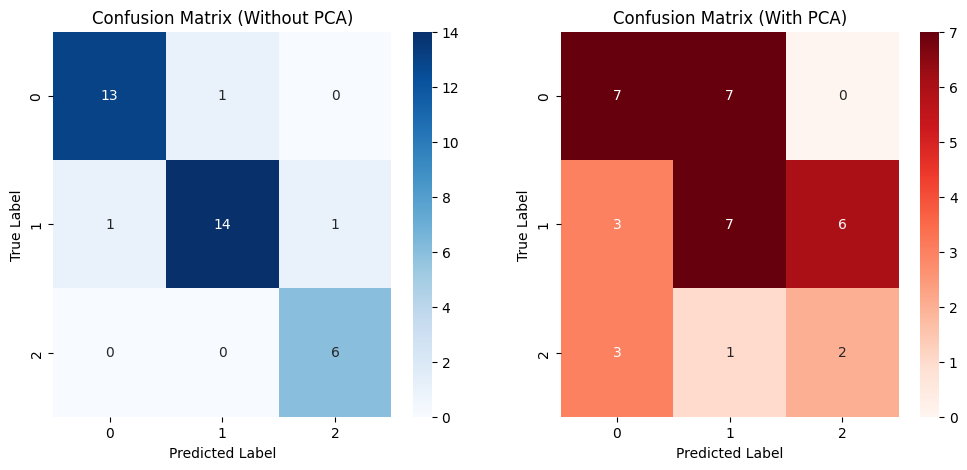

In [171]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_original), annot=True, fmt="d", cmap="Blues", ax=ax[0])
ax[0].set_title("Confusion Matrix (Without PCA)")
ax[0].set_xlabel("Predicted Label")
ax[0].set_ylabel("True Label")

sns.heatmap(confusion_matrix(y_test, y_pred_pca), annot=True, fmt="d", cmap="Reds", ax=ax[1])
ax[1].set_title("Confusion Matrix (With PCA)")
ax[1].set_xlabel("Predicted Label")
ax[1].set_ylabel("True Label")

plt.show()

In [172]:
import plotly.express as px

df_pca = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2', 'PC3'])

df_pca['Target'] = y_train.astype(str)  

fig = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3', 
                     color='Target', 
                     title="3D PCA Projection",
                     labels={'Target': 'Class'}) 
fig.show()

# Thank You